# Ultimate Data Challenge

## Part 1 : EDA

The attached logins.json file contains (simulated) timestamps of user logins in a particular
geographic location. I'll start the analysis by importing relavant libraries, loading the data and converting it do a dataframe (df).  I'll then aggregate the login counts by 15 minute time intervals in order to visualize and describe the resulting time series of login counts in ways that best characterize the underlying patterns of the demand. 

In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [129]:
with open('logins.json', 'r') as file:
    data = json.load(file)

print(json.dumps(data, indent=4))

{
    "login_time": [
        "1970-01-01 20:13:18",
        "1970-01-01 20:16:10",
        "1970-01-01 20:16:37",
        "1970-01-01 20:16:36",
        "1970-01-01 20:26:21",
        "1970-01-01 20:21:41",
        "1970-01-01 20:12:16",
        "1970-01-01 20:35:47",
        "1970-01-01 20:35:38",
        "1970-01-01 20:47:52",
        "1970-01-01 20:26:05",
        "1970-01-01 20:31:03",
        "1970-01-01 20:34:46",
        "1970-01-01 20:36:34",
        "1970-01-01 20:39:25",
        "1970-01-01 20:40:37",
        "1970-01-01 20:34:58",
        "1970-01-01 20:43:59",
        "1970-01-01 20:47:46",
        "1970-01-01 20:46:34",
        "1970-01-01 20:56:07",
        "1970-01-01 20:49:12",
        "1970-01-01 20:59:06",
        "1970-01-01 20:59:59",
        "1970-01-01 21:15:01",
        "1970-01-01 21:09:24",
        "1970-01-01 21:19:24",
        "1970-01-01 21:20:53",
        "1970-01-01 21:29:19",
        "1970-01-01 21:58:05",
        "1970-01-01 21:51:51",
        "1970-01-

Our data is in the format of a dictionary.  Let's transform it into a dataframe for easier processing.

In [130]:
#Convert logins to a df
logins = pd.DataFrame(list(data['login_time']))
logins.rename(columns={0: 'login_time'}, inplace=True)

Grouping by 15 minute time intervals will ignore month and day unless we include those arguements specifically.  I'll do this by pulling the month and day into their own columns.  

In [131]:
#Extract the month and day, set time to index in preparation for grouping 
logins['datetime'] = pd.to_datetime(logins['login_time'])
logins['month'] = logins['datetime'].dt.month
logins['day'] = logins['datetime'].dt.day
logins = logins.set_index('datetime')
logins

,login_time,month,day
datetime,,,
1970-01-01 20:13:18,1970-01-01 20:13:18,1,1
1970-01-01 20:16:10,1970-01-01 20:16:10,1,1
1970-01-01 20:16:37,1970-01-01 20:16:37,1,1
1970-01-01 20:16:36,1970-01-01 20:16:36,1,1
1970-01-01 20:26:21,1970-01-01 20:26:21,1,1
...,...,...,...
1970-04-13 18:50:19,1970-04-13 18:50:19,4,13
1970-04-13 18:43:56,1970-04-13 18:43:56,4,13
1970-04-13 18:54:02,1970-04-13 18:54:02,4,13


Now we can group by 15 minute intervals without combining data ooccuring on different days.  In order to plot this data, we'll need to combine the time interval labels back into a datetime label with month and year to make a new complete datetime label that we will call 'datetime'.

In [139]:
#Group data by 15min intervals, counting the number of logins for each interval
logins_15min = logins.groupby(['month', 'day', (logins.index.floor('15min').time)]).count()
logins_15min.reset_index(inplace=True)
logins_15min.rename(columns={'level_2': '15min_intervals', 'login_time':'counts'}, inplace=True)
logins_15min['datetime'] = (pd.to_datetime(dict(year=1970, month = logins_15min['month'], day=logins_15min['day'])) + pd.to_timedelta(logins_15min['15min_intervals'].astype(str)))

logins_15min.head()

,month,day,15min_intervals,counts,datetime
0,1,1,20:00:00,2,1970-01-01 20:00:00
1,1,1,20:15:00,6,1970-01-01 20:15:00
2,1,1,20:30:00,9,1970-01-01 20:30:00
3,1,1,20:45:00,7,1970-01-01 20:45:00
4,1,1,21:00:00,1,1970-01-01 21:00:00


Now we can plot the grouped data.

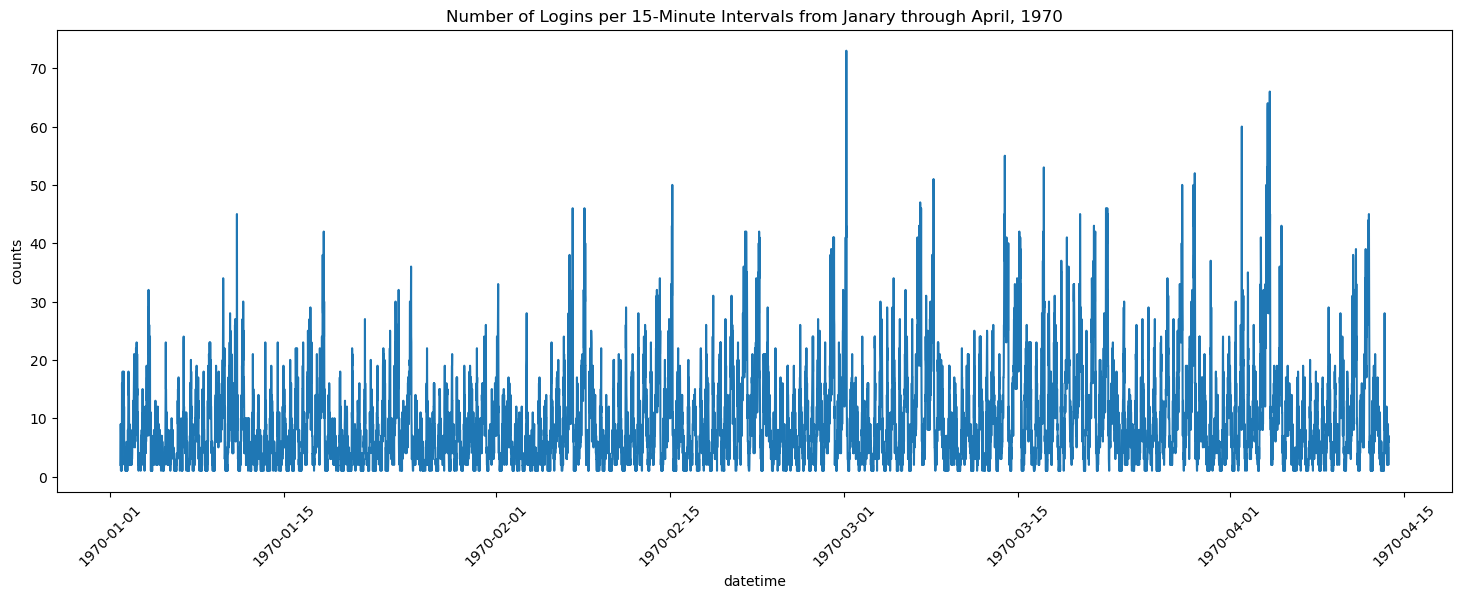

In [140]:
logins_15min['15min_intervals'] = logins_15min['15min_intervals'].astype('str')
fig, ax = plt.subplots(figsize=(18, 6))
sns.lineplot(data=logins_15min, x='datetime', y='counts')
plt.title('Number of Logins per 15-Minute Intervals from Janary through April, 1970')
plt.xticks(rotation=45)
plt.show()


From this plot, we learn the following:
1. Logins per 15 minute intervals range from 0 to 70 logins.  
2. Most intervals have less than 30 logins
3. The spikes in logins appear regular, so there is likely to be some periodicity in this data.
4. Spikes in logins seem to get larger and more frequent as time progresses from January through April.

In order to see the data better, I'll plot each month separately.

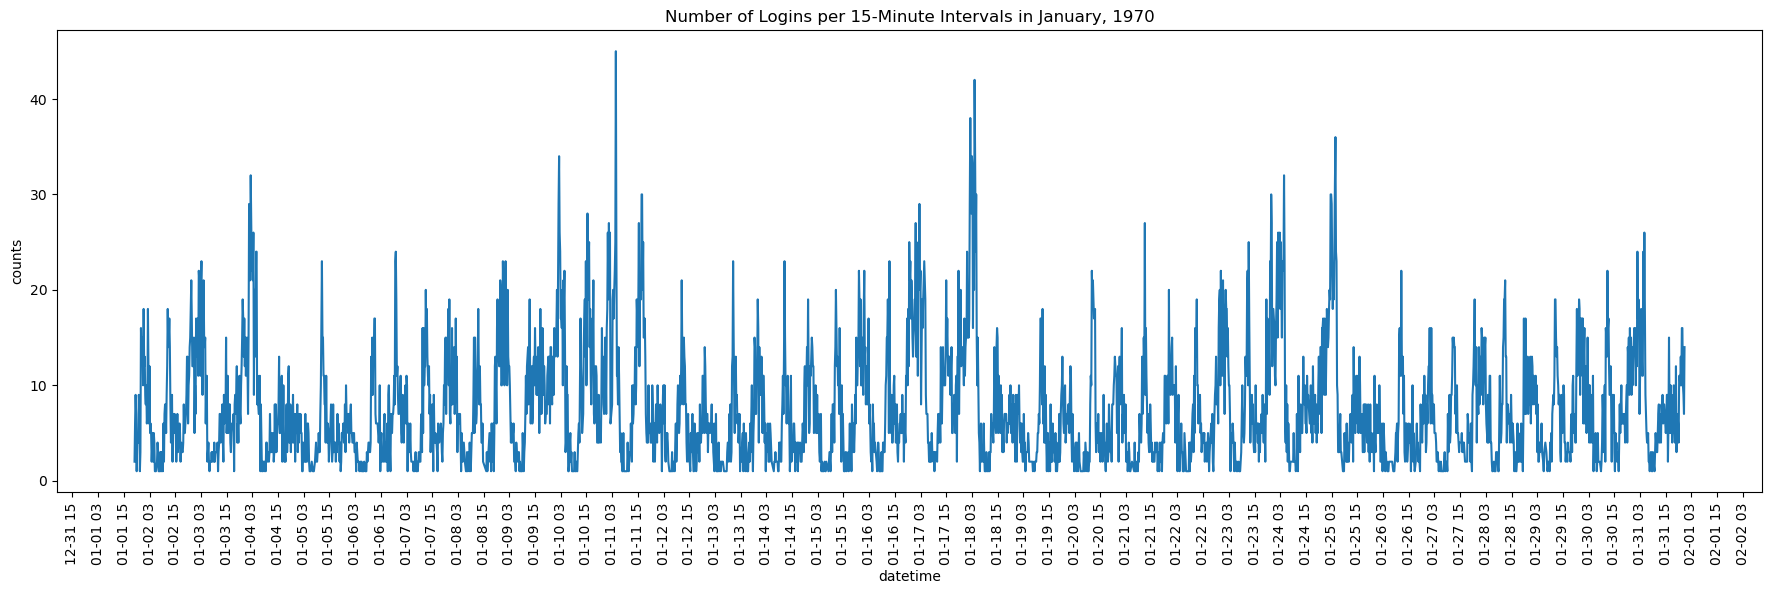

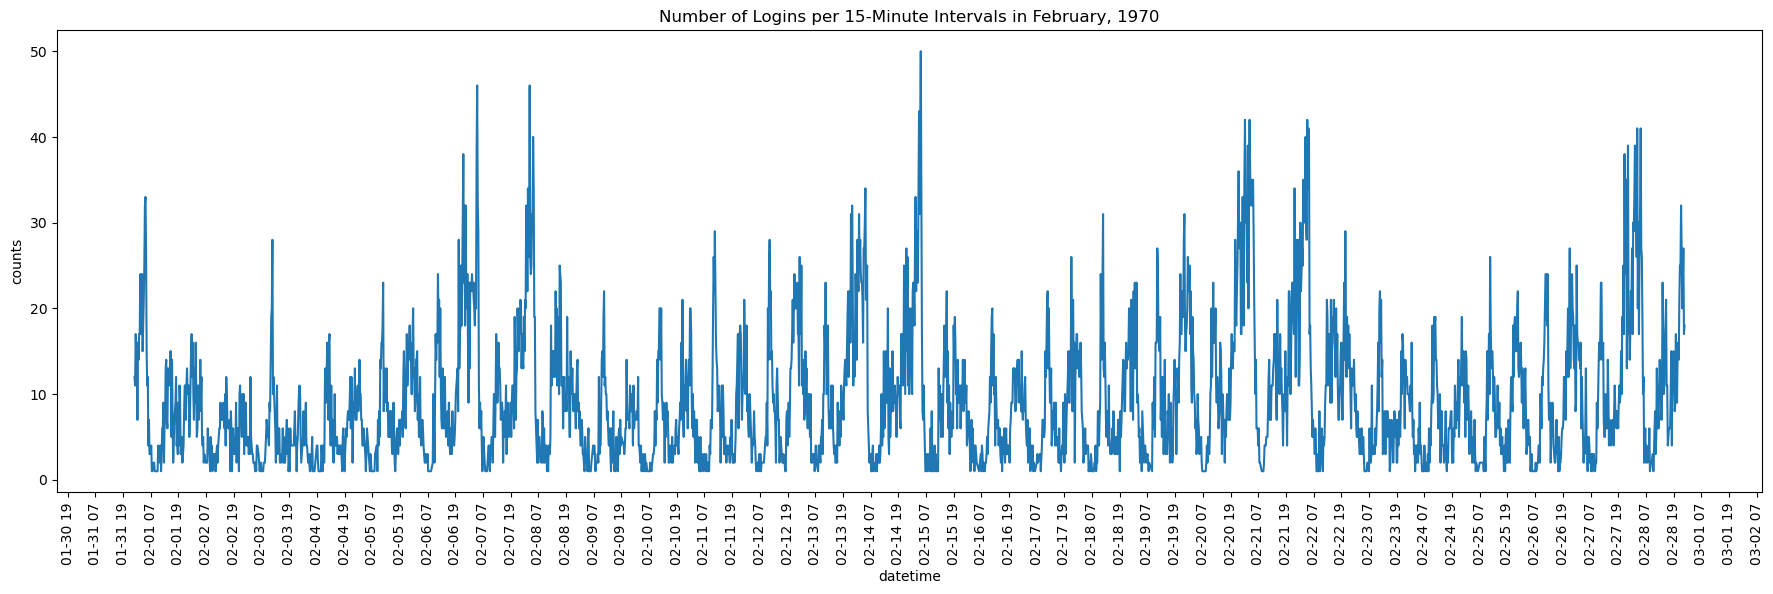

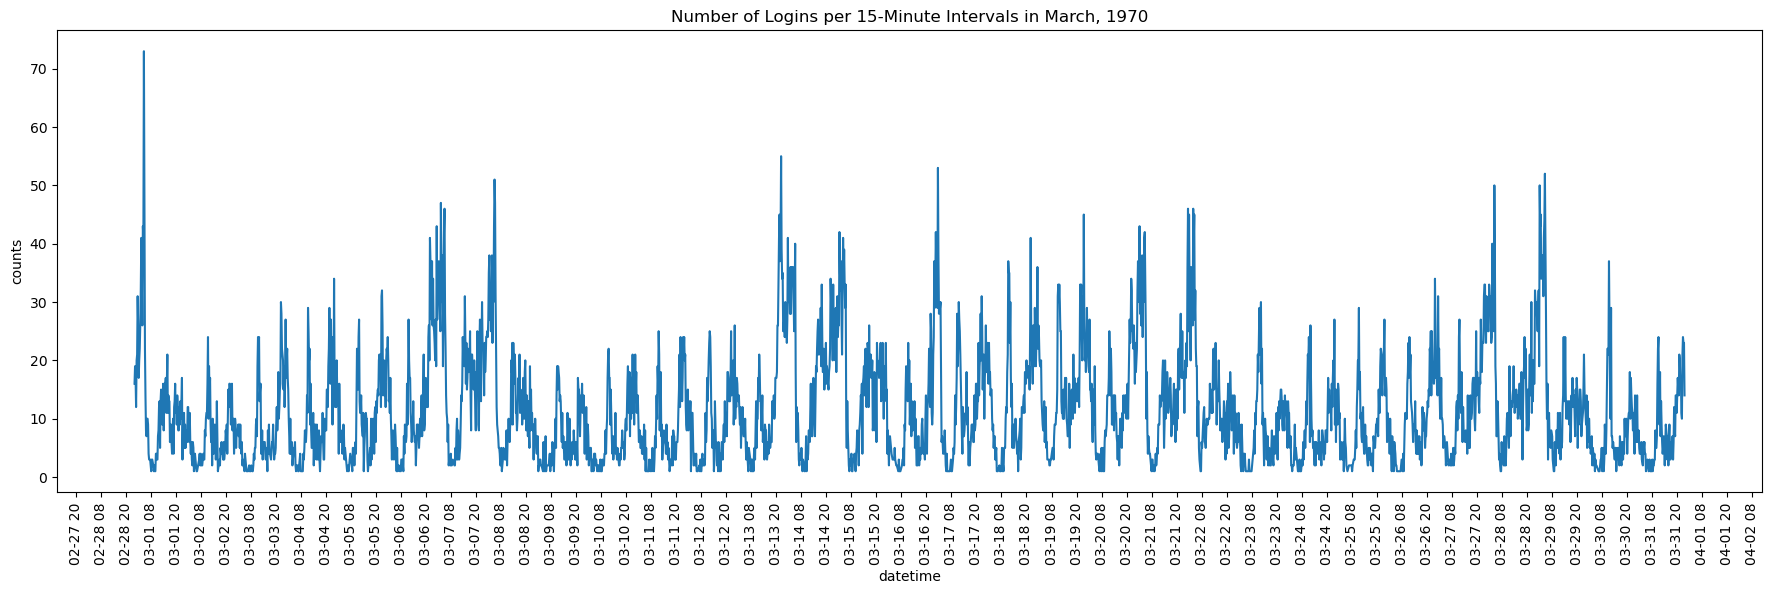

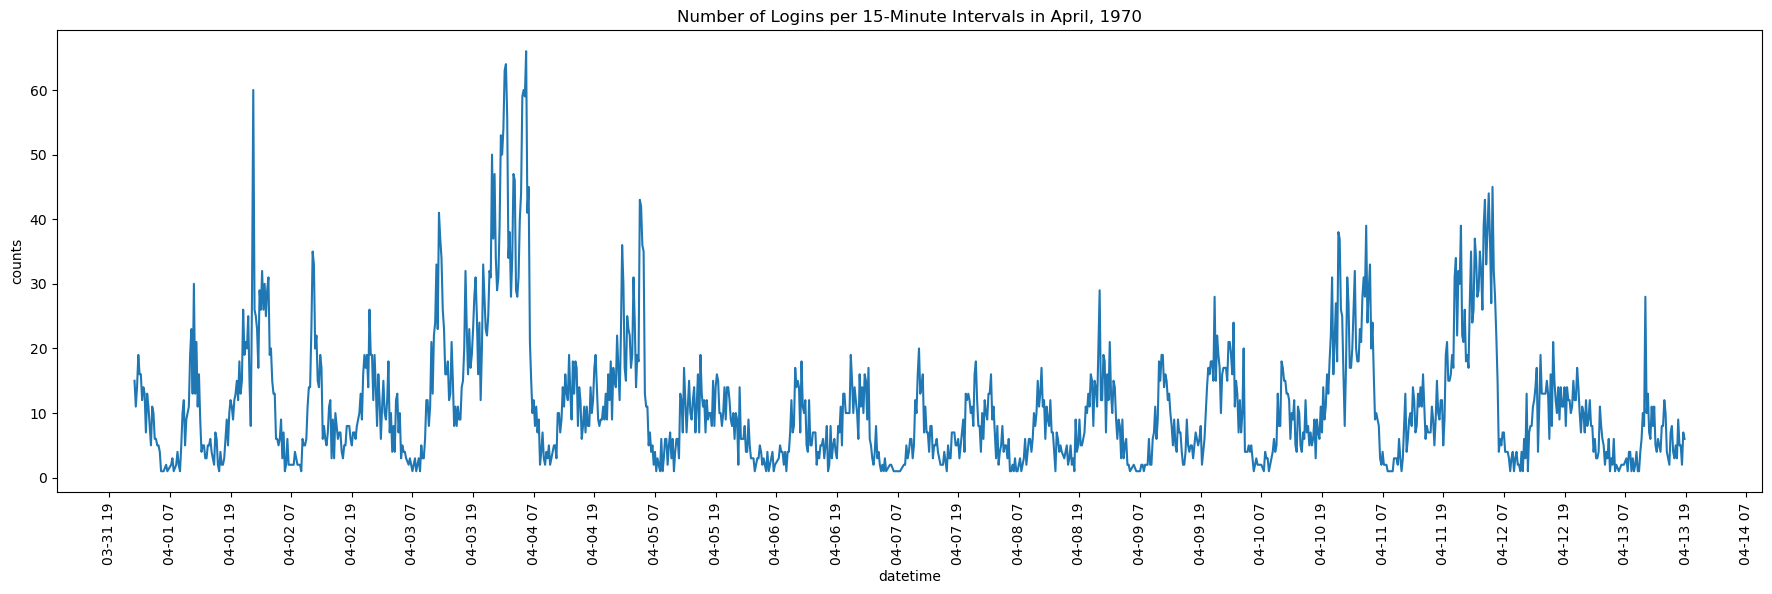

In [141]:
import matplotlib.dates as mdates

months = {1: 'January', 2: 'February', 3: 'March', 4: 'April'}

for m in [1, 2, 3, 4]:
    month_df = logins_15min[logins_15min['month'] == m]
    fig, ax = plt.subplots(figsize=(22, 6))
    sns.lineplot(data=month_df, x='datetime', y='counts')
    plt.title(f'Number of Logins per 15-Minute Intervals in {months[m]}, 1970')
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=12))
    plt.xticks(rotation=90)
    plt.show()

From these plots, we learn the following:

1. Each month appears to follow a similar pattern.
2. I think there are 1-2 spikes in logins per day, but it's not quite clear yet. But there seems to be daily periodicity.
3. Logins are higher every 7 days, for approximaetly two days.  In March, 2nd-4rth, 9th-11th, 17th-18th and 23rd-25th.  Similar atterns are seen in each month (April is the easiest to see since we only have 15 days of data - 3rd-4rth and 10th-11th have the most usage.)  I'm guessing these are the weekends. Not only that, with our x-axis having ticks every 12 hours, we can see that the increaed logins will often start with second have of the "Friday" and go to the first part of "Sunday".  
4. If we take these highest peaks as the weekends, there might also be a steady increase in peak size from Monday to Friday, but this is speculation at this point.

For the moment, let's ignore everything we just said about weekends and focus take a look at the pattern over each day. We can do this by plotting the '15min interval' column in our grouped df that only has a time label and no day/month label.

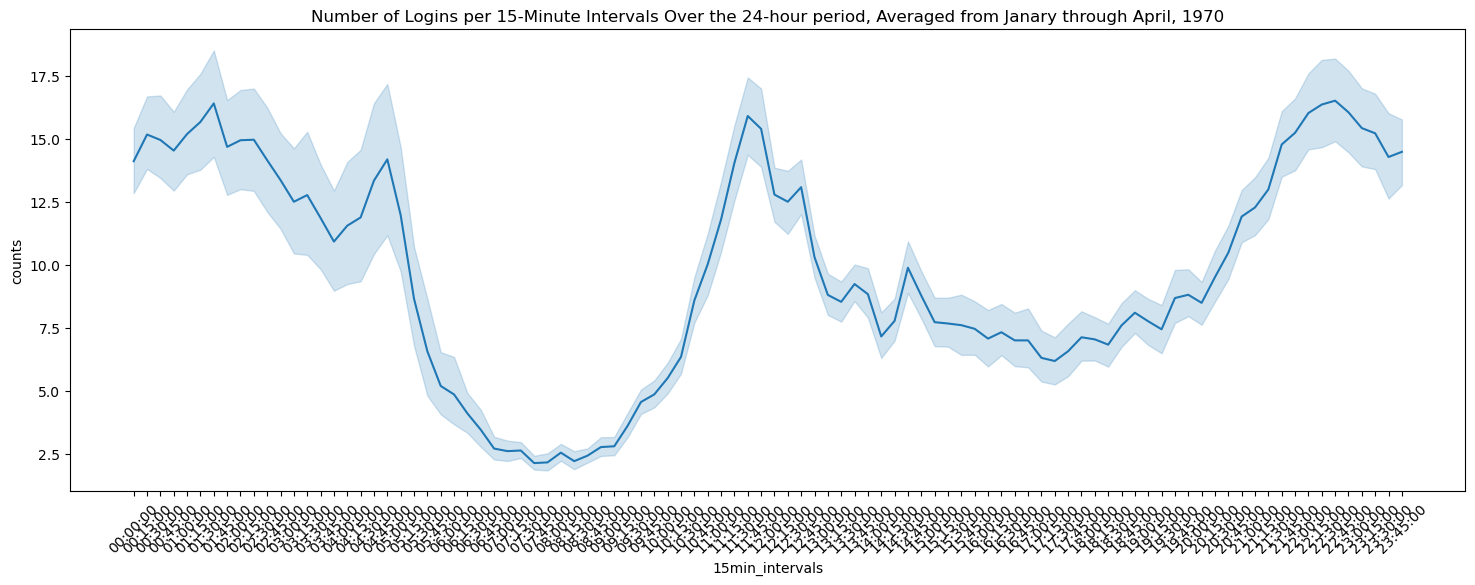

In [142]:
logins_15min['15min_intervals'] = logins_15min['15min_intervals'].astype('str')
logins_24hours = logins_15min.sort_values('15min_intervals')

fig, ax = plt.subplots(figsize=(18, 6))
sns.lineplot(data=logins_24hours, x='15min_intervals', y='counts')
plt.title('Number of Logins per 15-Minute Intervals Over the 24-hour period, Averaged from Janary through April, 1970')
plt.xticks(rotation=45)
plt.show()

This shows a clear pattern over 24 hours.  
1. Logins are highest from 21:45 through 4:30 the next morning.
2. From 4:30 to 6:15 logins drop quickly to and stay low until 8:45.
3. Logins then rise precipitously again from 8:45 to 10:45, were there have a spike.
4. Logins drop until about 12:45 (looks like everyone logged in at lunch) and stay at an intermediate level until 19:30 when they trise again to repeat the pattern.

The details of the above are mostly for my benefit and the times should not be considered exact.  The overall trend is high at night, very low in the early mornings, high at mid-day, intermediate for the afternoon, and high in the evening.  This tells us a few things about the users of this website.

1. Clearly, logins are not happening during normal working hours.  This tells us that users are most likely logging in for personal reasons, not for there jobs.
2. High logins are maintained all night.  I find this interestingly and not something you would expect for a the typical user who would go to bed.  I speculate that this website attracts users who are up late at night, probably don't have small children and are probabaly fairly young in order to maintain this lifestyle. This is what I would expect for a video game website, as an example.

Before moving back to weekly or monthly trends, lets' look at the daily trend as a scatterplot so we can see individual data points instead of averages.

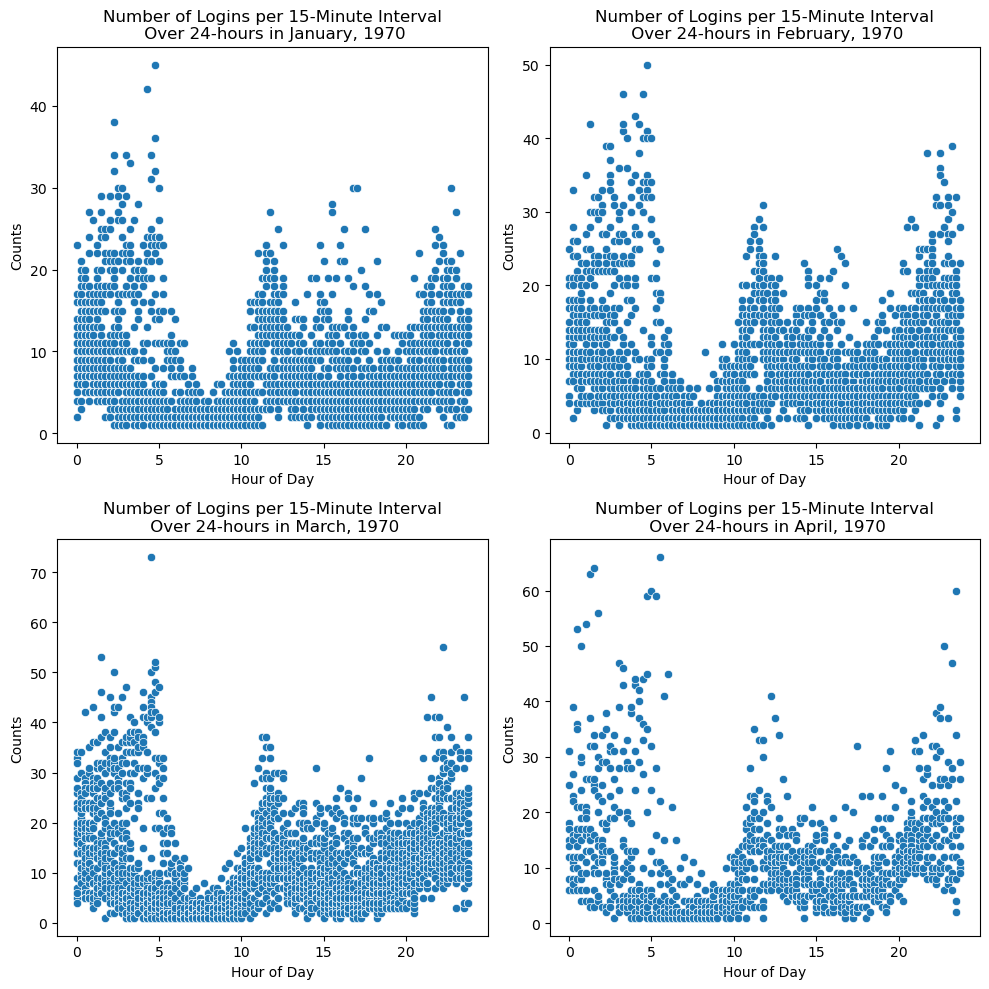

In [143]:
logins_24hours['hour'] = logins_24hours['datetime'].dt.hour + logins_24hours['datetime'].dt.minute/60

fig, ax = plt.subplots(2, 2, figsize=(10, 10))
axes = ax.flatten()
for i, m in enumerate([1, 2, 3, 4]):
    month_df = logins_24hours[logins_24hours['month'] == m]
    sns.scatterplot(data=month_df, x='hour', y='counts', ax=axes[i])
    axes[i].set_title(f'Number of Logins per 15-Minute Interval\n Over 24-hours in {months[m]}, 1970', fontsize=12)
    axes[i].set_xlabel('Hour of Day')
    axes[i].set_ylabel('Counts')
plt.tight_layout()
plt.show()


The above plot confirms the trend already described and adds the following:
1. The highest spikes in usage are from midnight/1am to 5am/6am.
2. Usuage over 'lunch' is more moderate with few very high data points.  This pattern might be why it was hard to tell if we had 1 or 2 spikes per 24 hours when analyzing our line plots.  There is one large spike and sometimes a smaller one as well.
3. Login counts per 15 minutes over 40 seem to be increasing over time.  We can confirm this later.

Now that we understand the daily pattern, let's go back to our weekly trend.  We can start by assigning a new column to the day of the week, and another to weekday vs weekend.

In [145]:
weekends = {'Monday':'Weekday', 'Tuesday':'Weekday', 'Wednesday':'Weekday', 'Thursday':'Weekday', 'Friday':'Weekday', 'Saturday':'Weekend', "Sunday":'Weekend'}

logins_15min['day_of_week'] = logins_15min['datetime'].dt.day_name()
logins_15min['weekday'] = logins_15min['day_of_week'].map(weekends)
logins_15min.head()

,month,day,15min_intervals,counts,datetime,day_of_week,weekday
0,1,1,20:00:00,2,1970-01-01 20:00:00,Thursday,Weekday
1,1,1,20:15:00,6,1970-01-01 20:15:00,Thursday,Weekday
2,1,1,20:30:00,9,1970-01-01 20:30:00,Thursday,Weekday
3,1,1,20:45:00,7,1970-01-01 20:45:00,Thursday,Weekday
4,1,1,21:00:00,1,1970-01-01 21:00:00,Thursday,Weekday


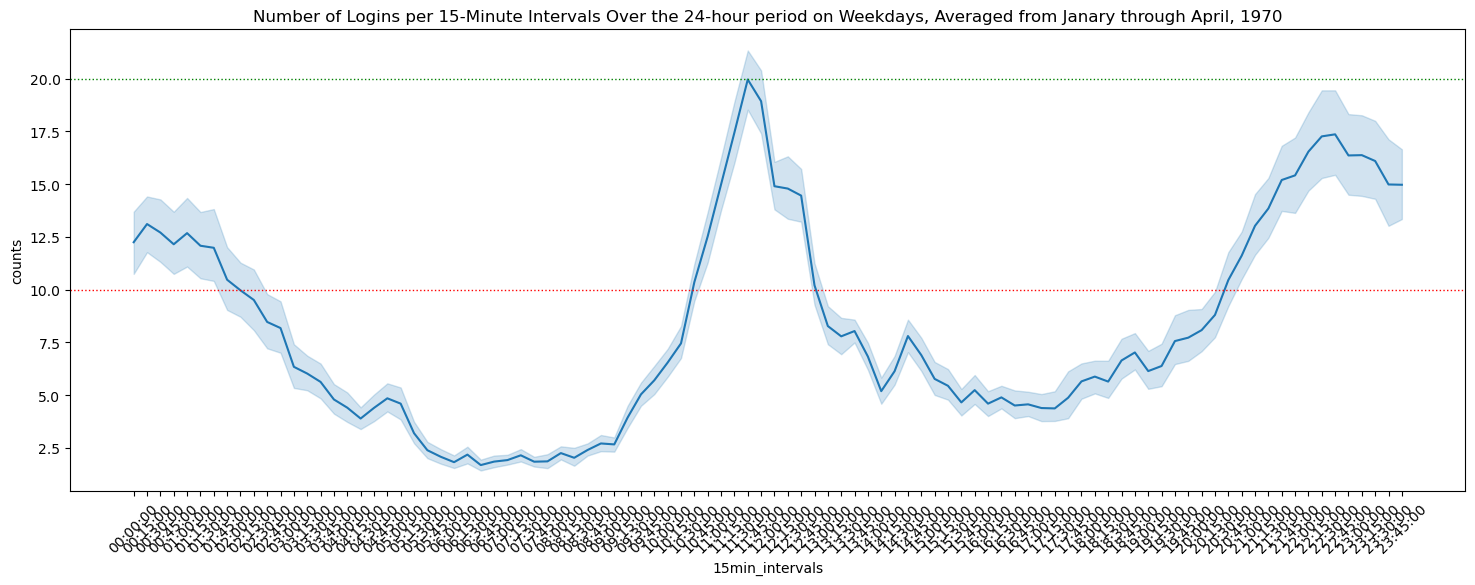

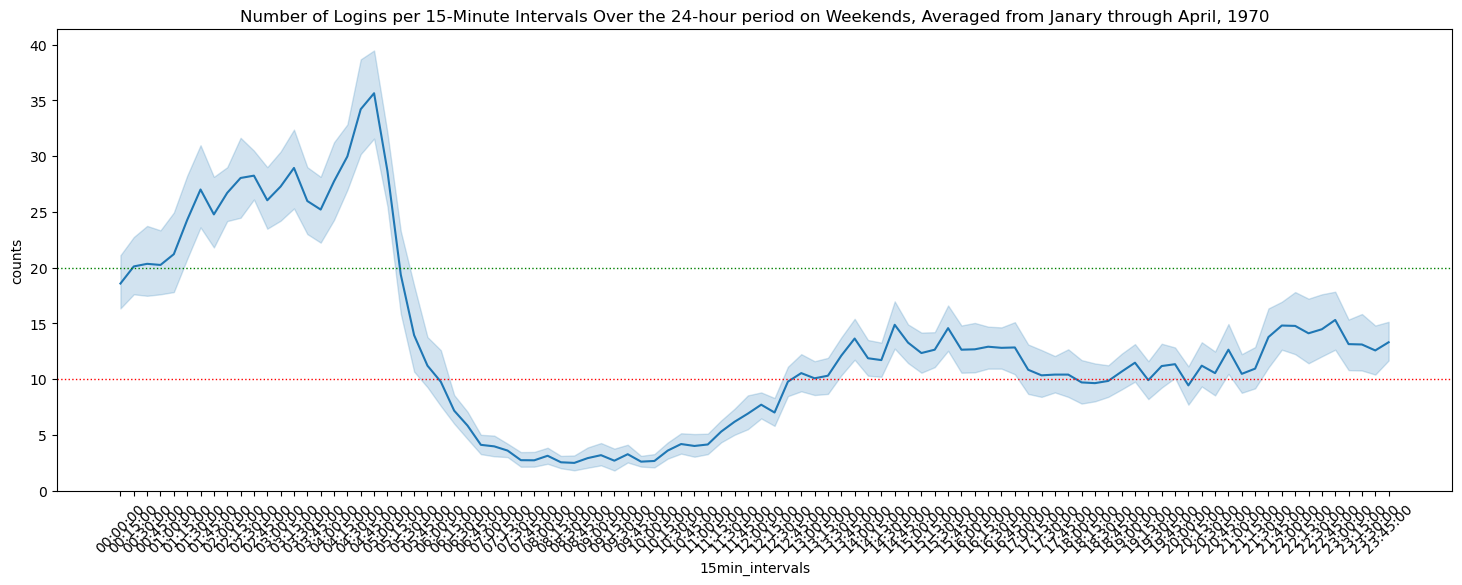

In [ ]:
logins_24hours_weekday = logins_15min[logins_15min['weekday'] == 'Weekday']
logins_24hours_weekend = logins_15min[logins_15min['weekday'] == 'Weekend']

logins_24hours_weekday = logins_24hours_weekday.sort_values('15min_intervals')
logins_24hours_weekend = logins_24hours_weekend.sort_values('15min_intervals')

fig, ax = plt.subplots(figsize=(18, 6))
sns.lineplot(data=logins_24hours_weekday, x='15min_intervals', y='counts')
plt.axhline(y=10, color='r', linestyle=':', linewidth=1)
plt.axhline(y=20, color='g', linestyle=':', linewidth=1)
plt.title('Average Logins per 15-Minute Intervals Over the 24-hour period on Weekdays, Averaged from Janary through April, 1970')
plt.xticks(rotation=45)
plt.show()

fig, ax = plt.subplots(figsize=(18, 6))
sns.lineplot(data=logins_24hours_weekend, x='15min_intervals', y='counts')
plt.axhline(y=10, color='r', linestyle=':', linewidth=1)
plt.axhline(y=20, color='g', linestyle=':', linewidth=1)
plt.title('Average Logins per 15-Minute Intervals Over the 24-hour period on Weekends, Averaged from Janary through April, 1970')
plt.xticks(rotation=45)
plt.show()

From the above plot, showing average logins per 15 minute intervals separated by weekends and weekdays, we learn the following:

1. Weekends and weekdays show the same general trend, but with key differences.
2. Weekdays: Highest activity is mid-day and evening, with notably less late night usage.  Y-axis goes to 20.
3. Weekends: Highest activity is late at night from 1am-5am.  There is no mid-day peak, but instead has steady moderate usage from 12:30 to midnight. Y-axis goes to 40.

This is definitly looking like a videogame steaming service, or something similar.  If the website owner is interested in knowing when to apply resources to meet increased demand, the answer is between midnight and 5am on Saturday and Sunday mornings.

Now let's look at this trend on a larger scope by overalying entire weeks.

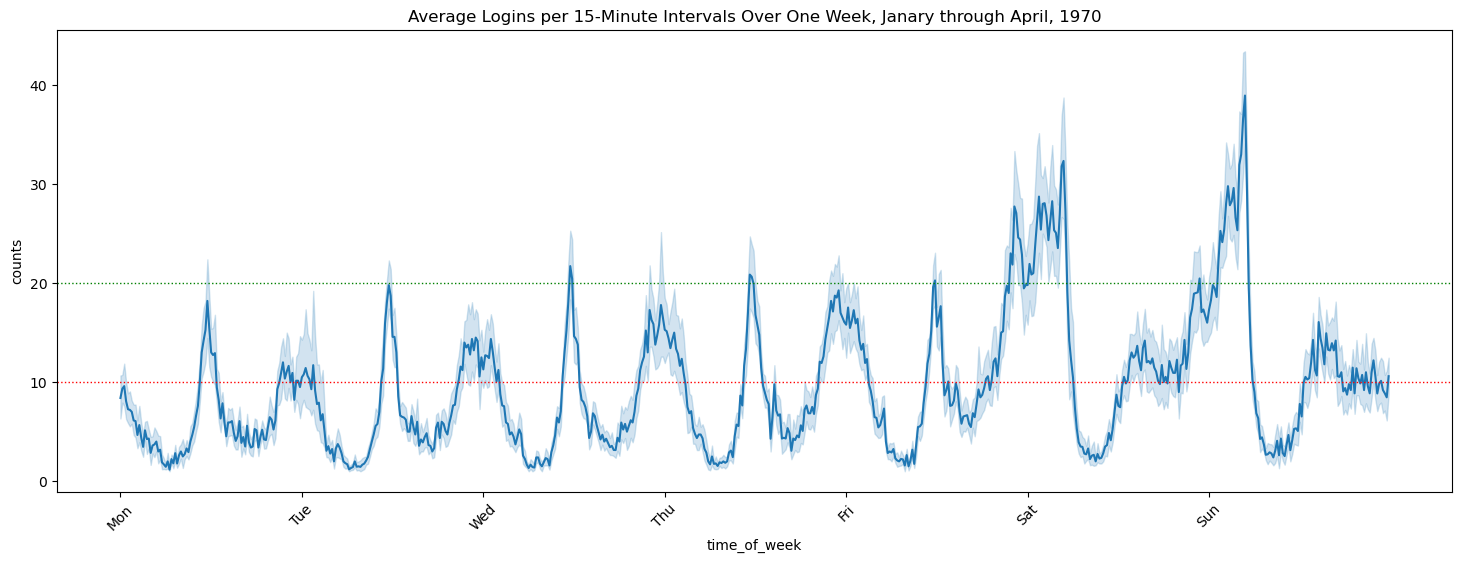

In [171]:
logins_15min['time_of_week'] = (logins_15min['datetime'].dt.dayofweek*96 + logins_15min['datetime'].dt.hour*4 + logins_15min['datetime'].dt.minute // 15)

fig, ax = plt.subplots(figsize=(18, 6))
sns.lineplot(data=logins_15min, x='time_of_week', y='counts', ax=ax)
plt.axhline(y=10, color='r', linestyle=':', linewidth=1)
plt.axhline(y=20, color='g', linestyle=':', linewidth=1)
plt.title('Average Logins per 15-Minute Intervals Over One Week, Janary through April, 1970')
day_positions = [0, 96, 192, 288, 384, 480, 576]
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
ax.set_xticks(day_positions)
ax.set_xticklabels(day_labels)
plt.xticks(rotation=45)
plt.show()

This plot shows us what the average week looks like.  Two peaks per weekday with a sharp peak around noon and lower, more sustained peek through the night. The noon peaks are similar thourgh the week, but the overnight highs increase from Monday through Thursday, with the highest usage periods Friday night/Saturday morning and Saturday night/Sunday morning.  Saturday and Sunday don't have afternoon peaks, but instead sustained moderate usage through the afternoon.

All of this tracks with a website that is used outside of working hours, by people whose schedule is determined by a typical 9-5 work requirement.  The users seem to care much less about maintaining the typical sleep schedule that often goes with 9-5 job.

Finally, we'll complete the EDA with doing some statistical tests.  I've claimed that usuage increases through the week with a high on the weekends and also suggested that usuage is increasing by month.  Let's find out if there are statistically significant differences to support these claims.

To help with this I've defined the following peaks:  
Peak #1: 10:15-12:15 everyday  
Peak #2_weekday: 20:30-23 Sunday through Thursday  
Peak #2_weekend: 1-5 Friday and Saturday

In [234]:
logins_15min['dow'] = logins_15min['datetime'].dt.dayofweek
logins_15min['time'] = logins_15min['datetime'].dt.time
peak1 = ((logins_15min['time'] >= dt.time(10,15)) & (logins_15min['time'] <= dt.time(12,15)))

weekday_peak2 = (
    (logins_15min['dow'] <= 3) &   # Mon–Thu, Sun
    (logins_15min['time'] >= dt.time(20,30)) &
    (logins_15min['time'] <= dt.time(23,0))
)

weekend_peak2 = (
    (logins_15min['dow'].isin([5,6])) &   #Sat and Sun Morning
    (logins_15min['time'] >= dt.time(0,0)) &
    (logins_15min['time'] <= dt.time(5,0))
)

conditions = [peak1, weekday_peak2, weekend_peak2]
choices = ['Peak#1', 'Peak#2_weekday', 'Peak#2_weekend']

logins_15min['period'] = np.select(conditions, choices, default = 'OffPeak')



Question #1: Do Peak#1 or Peak#2 differ by weekday?

Approach: Because we care more about the trend over the week, I will use a regression of counts vs day_of_week (this doesn't enforce order of the days, but it's a start) rather than an ANOVA which would pull out differences between any pairs of days.  I will then visualize with a violin plot.

In [ ]:
#Peak#1 first
logins_peaks = logins_15min.groupby(['period', 'dow', 'week'])['counts'].mean().reset_index()
peak1 = logins_peaks[(logins_peaks['period']== 'Peak#1') & (logins_peaks['dow'] <= 4)]
model = smf.ols('counts ~ dow', data=peak1).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 counts   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     1.604
Date:                Mon, 09 Mar 2026   Prob (F-statistic):              0.210
Time:                        14:17:35   Log-Likelihood:                -191.59
No. Observations:                  72   AIC:                             387.2
Df Residuals:                      70   BIC:                             391.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     13.8644      0.710     19.517      0.0

<function matplotlib.pyplot.show(close=None, block=None)>

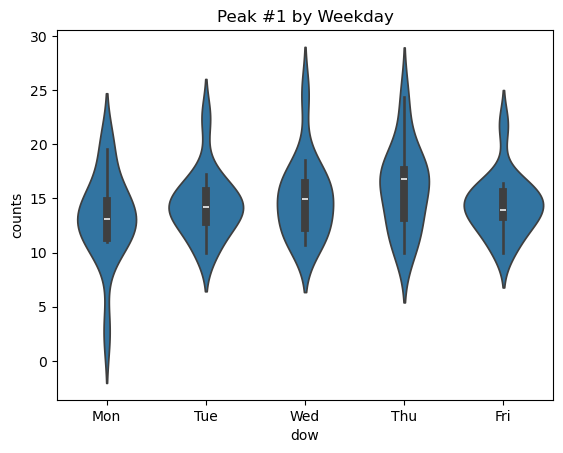

In [239]:
fig, ax = plt.subplots()
sns.violinplot(data=peak1, x='dow', y='counts', ax=ax)
plt.title("Peak #1 by Weekday")
day_positions = [0, 1, 2, 3, 4]
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']
ax.set_xticks(day_positions)
ax.set_xticklabels(day_labels)
plt.show

In [241]:
#Now Peak#2
logins_peaks = logins_15min.groupby(['period', 'dow', 'week'])['counts'].mean().reset_index()
peak2_weekday = logins_peaks[(logins_peaks['period']== 'Peak#2_weekday') & (logins_peaks['dow'] <= 4)]
model = smf.ols('counts ~ dow', data=peak2_weekday).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 counts   R-squared:                       0.247
Model:                            OLS   Adj. R-squared:                  0.233
Method:                 Least Squares   F-statistic:                     18.00
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           8.53e-05
Time:                        14:20:06   Log-Likelihood:                -154.71
No. Observations:                  57   AIC:                             313.4
Df Residuals:                      55   BIC:                             317.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     10.2721      0.830     12.381      0.0

<function matplotlib.pyplot.show(close=None, block=None)>

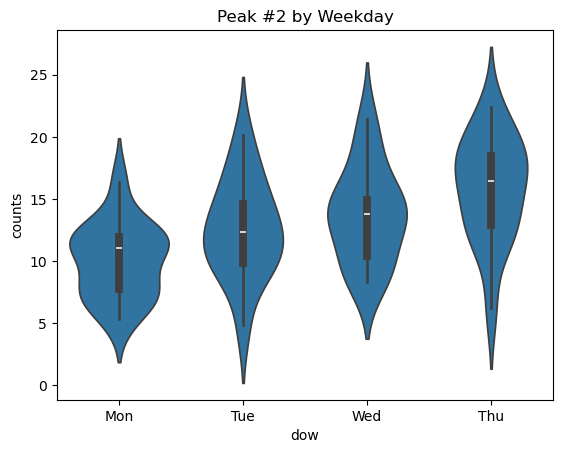

In [243]:
fig, ax = plt.subplots()
sns.violinplot(data=peak2_weekday, x='dow', y='counts', ax=ax)
plt.title("Peak #2 by Weekday")
day_positions = [0, 1, 2, 3]
day_labels = ['Mon', 'Tue', 'Wed', 'Thu']
ax.set_xticks(day_positions)
ax.set_xticklabels(day_labels)
plt.show

**Result: There is no difference in Peak#1 by Day of the Week.  Peak#2 increases by 1.86 logins per 15-minute interval each day from Monday to Thursday.  This trend is highly significant.**

Question #2: Does Peak #2 differ by weekday vs weekend?

Approach: Combine all weekdays today, keep Sat and Sun (midnight-5am) separate.  Perform one-way ANOVA with Tukey post-hoc pairwise analysis.  Visualize with a boxplot.

In [ ]:
peak2_day = logins_peaks[logins_peaks['period'] == 'Peak#2_weekday']
peak2_Sat = logins_peaks[(logins_peaks['period'] == 'Peak#2_weekend')&(logins_peaks['dow'] == 5)]
peak2_Sun = logins_peaks[(logins_peaks['period'] == 'Peak#2_weekend')&(logins_peaks['dow'] == 6)]
peak2_data = pd.concat([peak2_day[['counts']].assign(group="Weekday"), peak2_Sat[['counts']].assign(group="Saturday"), peak2_Sun[['counts']].assign(group="Sunday")])

tukey = pairwise_tukeyhsd(endog=peak2_data['counts'], groups=peak2_data['group'], alpha=.05)

print(tukey)


  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1   group2 meandiff p-adj   lower    upper  reject
--------------------------------------------------------
Saturday  Sunday   0.6505 0.9352  -3.8004  5.1013  False
Saturday Weekday -12.6912    0.0 -16.2284 -9.1541   True
  Sunday Weekday -13.3417    0.0 -16.8789 -9.8045   True
--------------------------------------------------------


<function matplotlib.pyplot.show(close=None, block=None)>

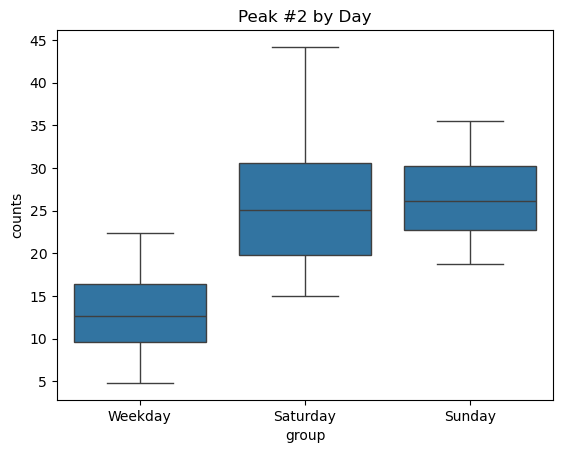

In [ ]:
fig, ax = plt.subplots()
sns.boxplot(data=peak2_data, x='group', y='counts', ax=ax)
plt.title("Peak #2: Weekday vs Weekend")
plt.show

**Result: Both Saturday and Sunday have higher Peak#2 (midnight - 5am) than weekdays.** Saturday increases by 12.7 logins per 15-minute interval compared to weekdays, and Sunday increases by 13.3 logins.  **These results are highly significant.**

Question #3: Does usage increase from January to April.

Approach: Perform regression by month.  If this doens't show a singnificant trend, try an ANOVA with Tukey post-hoc pairwise analysis, in case there is any pairwise difference of interest. Do this with all data and again with just the peaks. Visualize with a boxplot.

In [249]:
logins_month = logins_15min.groupby(['month', 'dow', 'week'])['counts'].mean().reset_index() #group data by day to avoid artifically increased sample number
model = smf.ols('counts ~ month', data=logins_month).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 counts   R-squared:                       0.186
Model:                            OLS   Adj. R-squared:                  0.178
Method:                 Least Squares   F-statistic:                     23.70
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           4.04e-06
Time:                        14:44:57   Log-Likelihood:                -274.86
No. Observations:                 106   AIC:                             553.7
Df Residuals:                     104   BIC:                             559.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.6027      0.773      8.545      0.0

<function matplotlib.pyplot.show(close=None, block=None)>

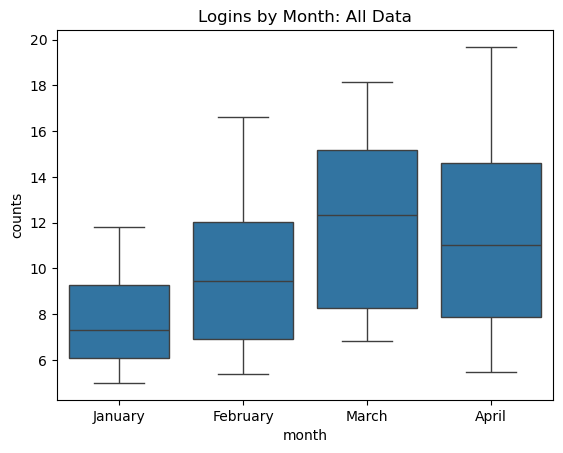

In [252]:
fig, ax = plt.subplots()
sns.boxplot(data=logins_month, x='month', y='counts')
plt.title("Logins by Month: All Data")
month_positions = [0, 1, 2, 3]
month_labels = ['January', 'February', 'March', 'April']
ax.set_xticks(month_positions)
ax.set_xticklabels(month_labels)
plt.show


In [253]:
logins_month_peaks = logins_15min[logins_15min['period'] != 'OffPeak']
logins_month_peaks = logins_month_peaks.groupby(['month', 'dow', 'week'])['counts'].mean().reset_index() 
model = smf.ols('counts ~ month', data=logins_month_peaks).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 counts   R-squared:                       0.264
Model:                            OLS   Adj. R-squared:                  0.257
Method:                 Least Squares   F-statistic:                     37.30
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           1.77e-08
Time:                        14:50:41   Log-Likelihood:                -297.49
No. Observations:                 106   AIC:                             599.0
Df Residuals:                     104   BIC:                             604.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     10.3773      0.957     10.848      0.0

<function matplotlib.pyplot.show(close=None, block=None)>

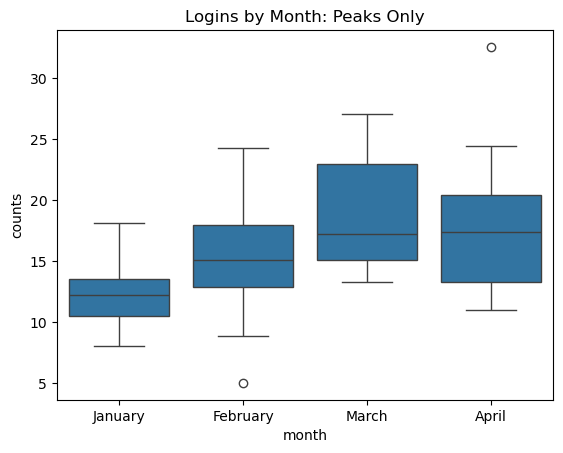

In [254]:
fig, ax = plt.subplots()
sns.boxplot(data=logins_month_peaks, x='month', y='counts')
plt.title("Logins by Month: Peaks Only")
month_positions = [0, 1, 2, 3]
month_labels = ['January', 'February', 'March', 'April']
ax.set_xticks(month_positions)
ax.set_xticklabels(month_labels)
plt.show


**Result: Usage in increasing by month, both in terms of all data and in terms of peak data.** Logins increase by 1.5 users per 15-minute interval over all intervals, and increase by 2.3 users over peak intervals.  **These results are highly significant.**

This concludes our EDA of `logins.json`.

## Part 2: Experiment and Metrics Design

The attached logins.json file contains (simulated) timestamps of user logins in a particular
geographic location. I'll start the analysis by importing relavant libraries, loading the data and converting it do a dataframe (df).  I'll then aggregate the login counts by 15 minute time intervals in order to visualize and describe the resulting time series of login counts in ways that best characterize the underlying patterns of the demand. 